# EDA & Tiền xử lý — Phát hiện bất thường KHÔNG giám sát (T1.csv)

Notebook phân tích dữ liệu SCADA tuabin gió thật (`T1.csv`, năm 2018, bước 10 phút). Dữ liệu **không có nhãn** nên đây là bài toán phát hiện bất thường **không giám sát**: ta mô hình hóa trạng thái "bình thường" (đường cong công suất theo tốc độ gió) và đánh dấu các điểm lệch mạnh.

Hai module dùng lại:
1. `preprocessing.py` — xử lý missing values, outliers, chuẩn hóa, chia train/test theo thời gian.


In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os, sys

# --- Tự dò PROJECT_ROOT chứa src/ và data/ ---
_p = os.getcwd()
for _ in range(6):
    if os.path.isdir(os.path.join(_p, 'src')) and os.path.isdir(os.path.join(_p, 'data')):
        break
    _p = os.path.dirname(_p)
PROJECT_ROOT = _p
SRC_DIR = os.path.join(PROJECT_ROOT, 'src')
RAW_DIR = os.path.join(PROJECT_ROOT, 'data', 'raw')
PROCESSED_DIR = os.path.join(PROJECT_ROOT, 'data', 'processed')
FEATURES_DIR = os.path.join(PROJECT_ROOT, 'data', 'features')
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(FEATURES_DIR, exist_ok=True)
sys.path.insert(0, SRC_DIR)

import preprocessing as prep
import feature_engineering as feat

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
print('Đã nạp thư viện & module thành công!')

Đã nạp thư viện & module thành công!


## 1. Đọc dữ liệu & khảo sát ban đầu


In [2]:
csv_path = os.path.join(RAW_DIR, 'T1.csv')
df = prep.load_data(csv_path)
print('Kích thước sau khi reindex lưới thời gian:', df.shape)
df.head()

Kích thước sau khi reindex lưới thời gian: (52560, 5)


,timestamp,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,259.994904
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,268.641113
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,272.564789
3,2018-01-01 00:30:00,419.645904,5.659674,516.127569,271.258087
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,265.674286


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 52560 entries, 0 to 52559
Data columns (total 5 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   timestamp                      52560 non-null  datetime64[us]
 1   LV ActivePower (kW)            50530 non-null  float64       
 2   Wind Speed (m/s)               50530 non-null  float64       
 3   Theoretical_Power_Curve (KWh)  50530 non-null  float64       
 4   Wind Direction (°)             50530 non-null  float64       
dtypes: datetime64[us](1), float64(4)
memory usage: 2.0 MB


In [4]:
df.describe().round(2)

,timestamp,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind Direction (°)
count,52560,50530.00,50530.00,50530.00,50530.00
mean,2018-07-02 11:55:00,1307.68,7.56,1492.18,123.69
min,2018-01-01 00:00:00,-2.47,0.00,0.00,0.00
25%,2018-04-02 05:57:30,50.68,4.20,161.33,49.32
50%,2018-07-02 11:55:00,825.84,7.10,1063.78,73.71
75%,2018-10-01 17:52:30,2482.51,10.30,2964.97,201.70
max,2018-12-31 23:50:00,3618.73,25.21,3600.00,360.00
std,NaN,1312.46,4.23,1368.02,93.44


## 2. Chất lượng dữ liệu


In [5]:
num_cols = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)', 'Wind Direction (°)']
print('Khoảng thời gian:', df['timestamp'].min(), '->', df['timestamp'].max())
print('Tổng số mốc (lưới đều):', len(df))
print('\nSố giá trị khuyết mỗi cột (do mốc thời gian bị thiếu):')
print(df[num_cols].isnull().sum())
print(f"\nTỷ lệ khuyết: {df[num_cols].isnull().any(axis=1).mean()*100:.2f}%")

Khoảng thời gian: 2018-01-01 00:00:00 -> 2018-12-31 23:50:00
Tổng số mốc (lưới đều): 52560

Số giá trị khuyết mỗi cột (do mốc thời gian bị thiếu):
LV ActivePower (kW)              2030
Wind Speed (m/s)                 2030
Theoretical_Power_Curve (KWh)    2030
Wind Direction (°)               2030
dtype: int64

Tỷ lệ khuyết: 3.86%


## 3. Biến động tín hiệu theo thời gian

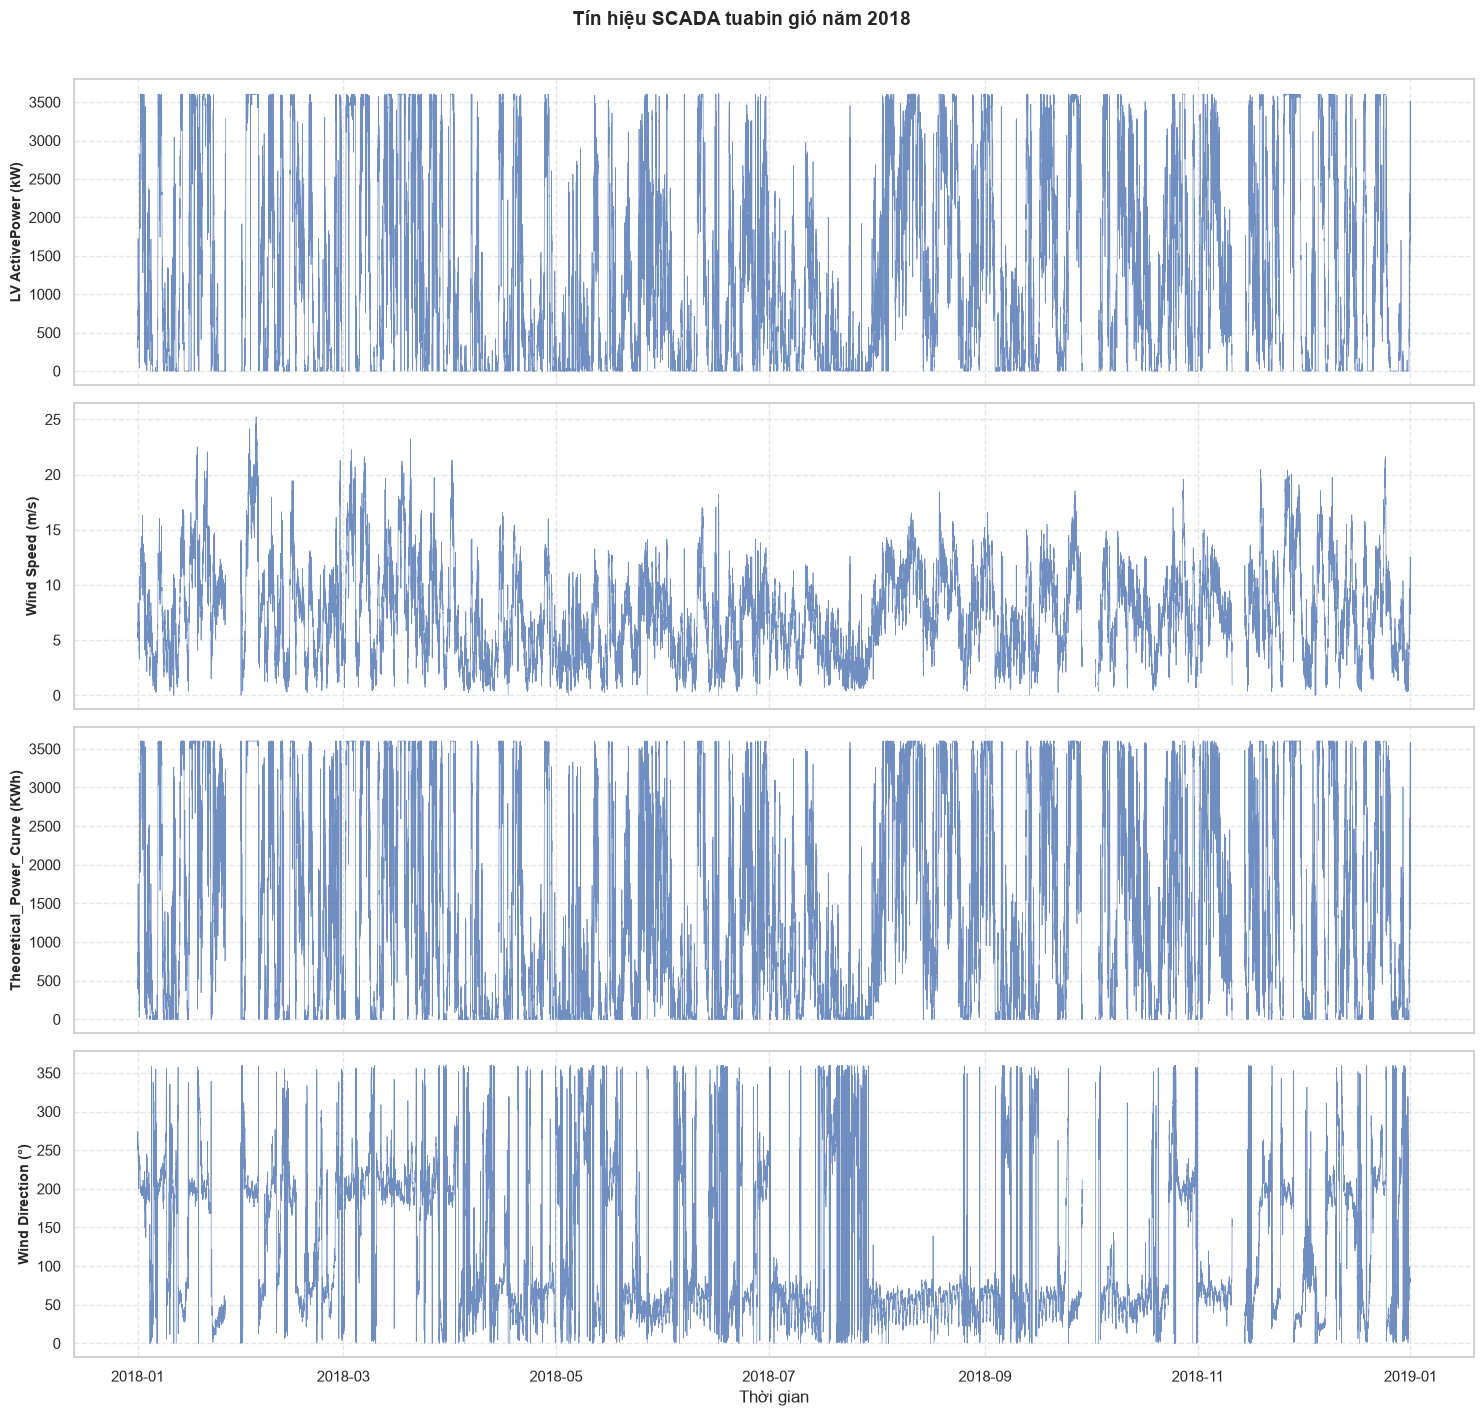

In [6]:
fig, axes = plt.subplots(len(num_cols), 1, figsize=(15, 14), sharex=True)
for i, col in enumerate(num_cols):
    axes[i].plot(df['timestamp'], df[col], color='#4c72b0', alpha=0.8, linewidth=0.5)
    axes[i].set_ylabel(col, fontsize=10, fontweight='bold')
    axes[i].grid(True, linestyle='--', alpha=0.5)
plt.xlabel('Thời gian')
plt.suptitle('Tín hiệu SCADA tuabin gió năm 2018', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

## 4. Phân phối tần suất các biến

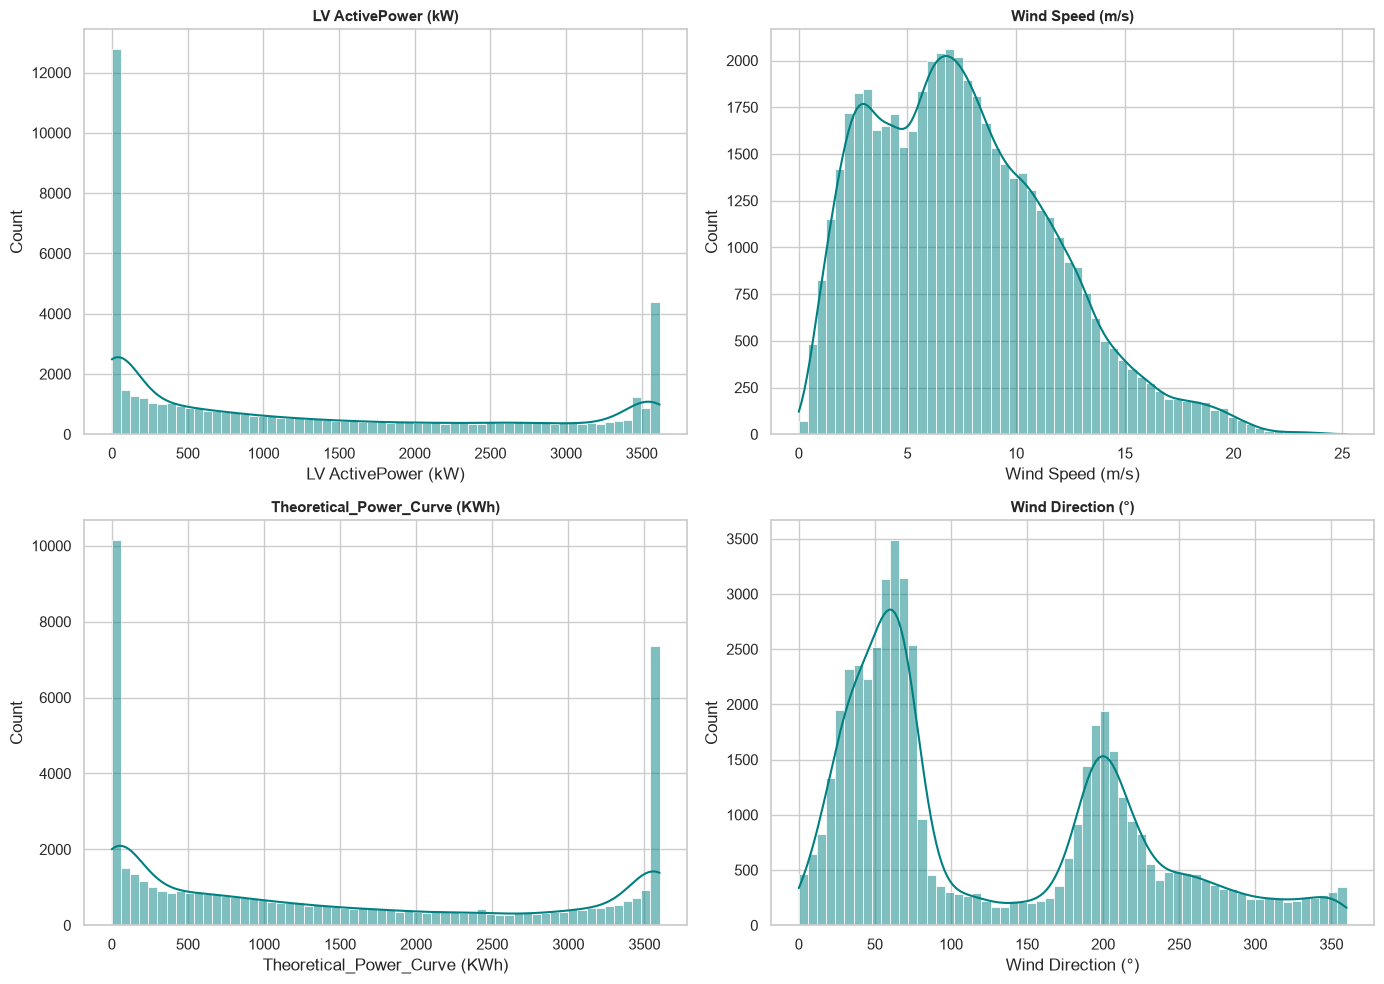

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10)); axes = axes.flatten()
for i, col in enumerate(num_cols):
    sns.histplot(data=df, x=col, kde=True, ax=axes[i], color='teal', bins=60)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
plt.tight_layout(); plt.show()

## 5. Ma trận tương quan

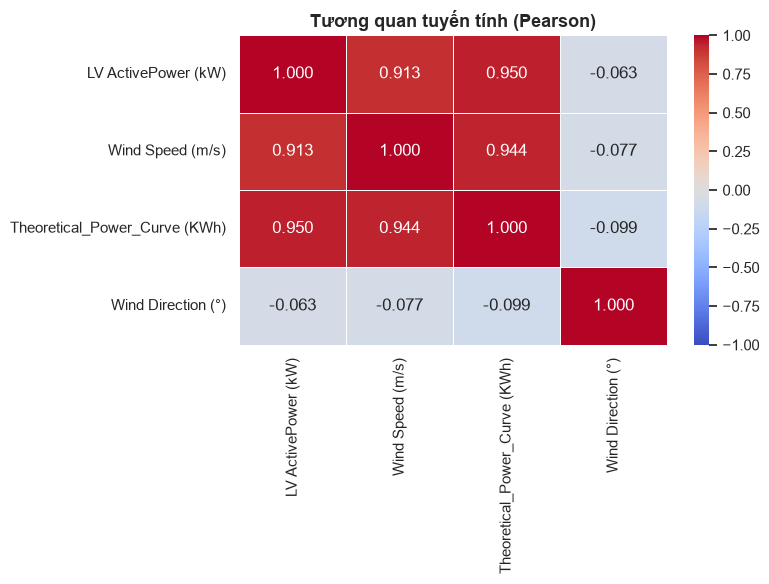

In [8]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt='.3f', vmin=-1, vmax=1, linewidths=0.5)
plt.title('Tương quan tuyến tính (Pearson)', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.show()

## 6. Phân tích đường cong công suất (Power Curve)


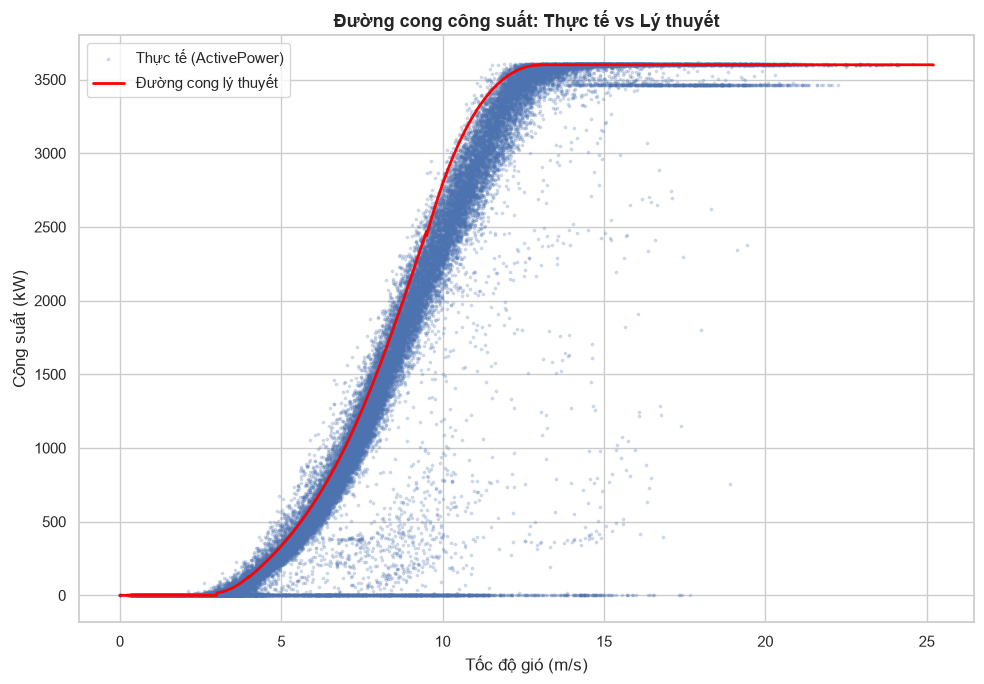

In [9]:
plt.figure(figsize=(10, 7))
plt.scatter(df['Wind Speed (m/s)'], df['LV ActivePower (kW)'], s=3, alpha=0.2, label='Thực tế (ActivePower)')
order = df['Wind Speed (m/s)'].argsort()
plt.plot(df['Wind Speed (m/s)'].iloc[order], df['Theoretical_Power_Curve (KWh)'].iloc[order],
         color='red', linewidth=2, label='Đường cong lý thuyết')
plt.xlabel('Tốc độ gió (m/s)'); plt.ylabel('Công suất (kW)')
plt.title('Đường cong công suất: Thực tế vs Lý thuyết', fontsize=13, fontweight='bold')
plt.legend(); plt.tight_layout(); plt.show()

## 7. Phần dư (residual) — tín hiệu bất thường


Số điểm ứng viên bất thường (|z|>3): 1469 (2.79%)


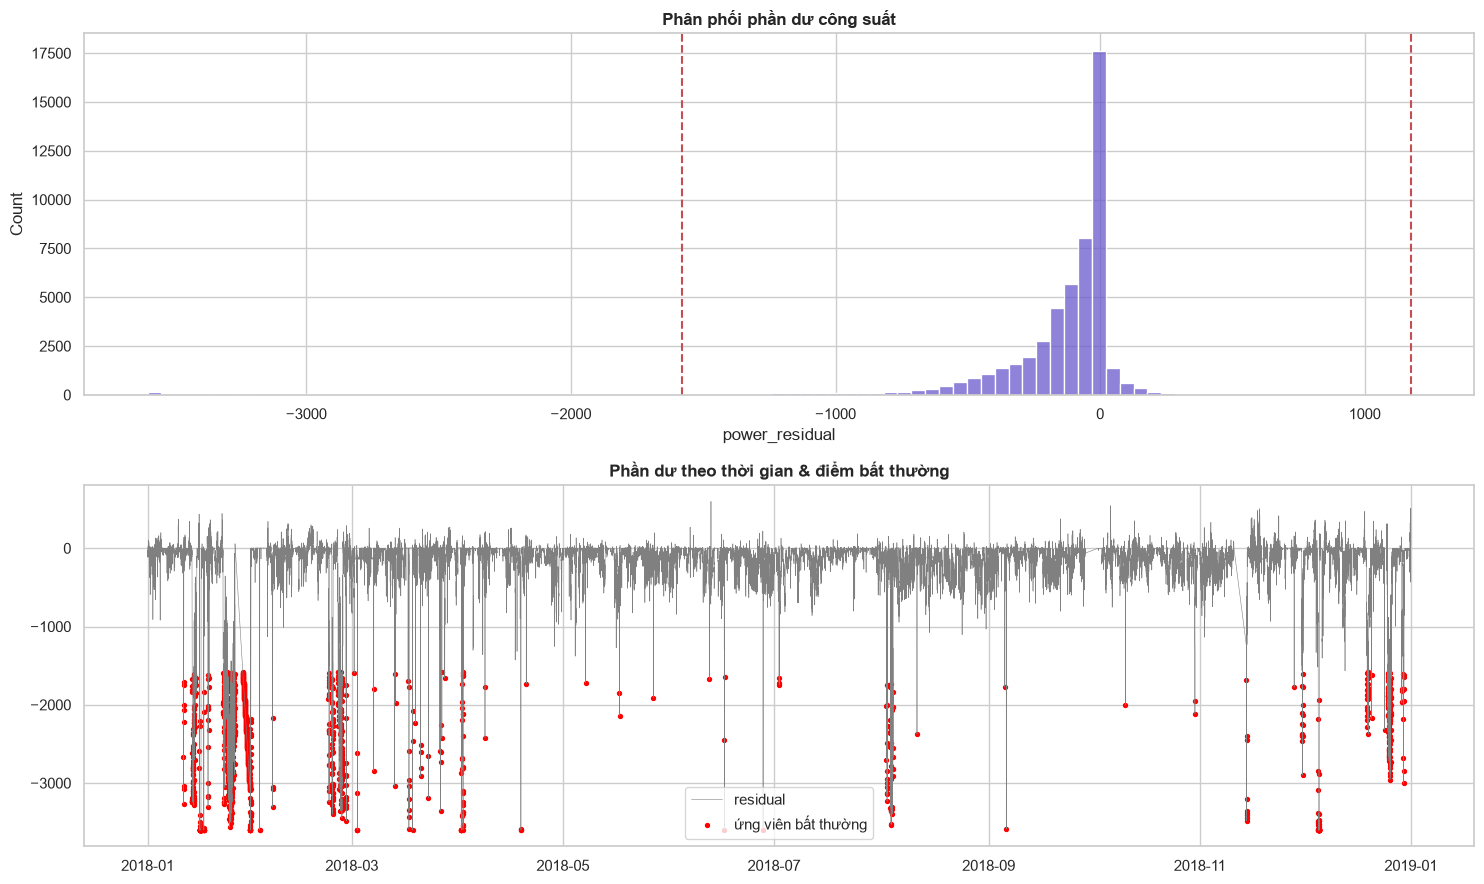

In [ ]:
df_r = prep.handle_missing_values(df, columns=num_cols, strategy='interpolate')
df_r['power_residual'] = df_r['LV ActivePower (kW)'] - df_r['Theoretical_Power_Curve (KWh)']
mu, sigma = df_r['power_residual'].mean(), df_r['power_residual'].std()
df_r['residual_z'] = (df_r['power_residual'] - mu) / sigma
df_r['anomaly_candidate'] = (df_r['residual_z'].abs() > 3).astype(int)
print(f"Số điểm ứng viên bất thường (|z|>3): {int(df_r['anomaly_candidate'].sum())} "
      f"({df_r['anomaly_candidate'].mean()*100:.2f}%)")

fig, axes = plt.subplots(2, 1, figsize=(15, 9))
sns.histplot(data=df_r, x='power_residual', bins=80, ax=axes[0], color='slateblue')
axes[0].set_title('Phân phối phần dư công suất', fontweight='bold')
axes[0].axvline(mu+3*sigma, color='r', ls='--'); axes[0].axvline(mu-3*sigma, color='r', ls='--')
axes[1].plot(df_r['timestamp'], df_r['power_residual'], lw=0.4, color='gray', label='residual')
anom = df_r[df_r['anomaly_candidate']==1]
axes[1].scatter(anom['timestamp'], anom['power_residual'], color='red', s=8, label='ứng viên bất thường')
axes[1].set_title('Phần dư theo thời gian & điểm bất thường', fontweight='bold'); axes[1].legend()
plt.tight_layout(); plt.show()

## 8. Tiền xử lý: missing & outliers


In [11]:
print('NaN trước khi xử lý:', int(df[num_cols].isnull().sum().sum()))
df_clean = prep.handle_missing_values(df, columns=num_cols, strategy='interpolate')
print('NaN sau interpolate:', int(df_clean[num_cols].isnull().sum().sum()))

NaN trước khi xử lý: 8120
NaN sau interpolate: 0


In [12]:
df_clean = prep.clean_physical_limits(df_clean)
df_clean = prep.encode_wind_direction(df_clean)
df_clean = prep.extract_time_features(df_clean)
df_clean = prep.create_labels(df_clean, loss_threshold=0.5)

print('Đã hoàn tất Pipeline tiền xử lý Vật lý & Lượng giác!')
display(df_clean.head())

Đã hoàn tất Pipeline tiền xử lý Vật lý & Lượng giác!


,timestamp,LV ActivePower (kW),Wind Speed (m/s),Theoretical_Power_Curve (KWh),Wind_Dir_Sin,Wind_Dir_Cos,Month,Hour,Loss,Label_Error
0,2018-01-01 00:00:00,380.047791,5.311336,416.328908,-0.984792,-0.173736,1,0,36.281117,0
1,2018-01-01 00:10:00,453.769196,5.672167,519.917511,-0.999719,-0.023715,1,0,66.148315,0
2,2018-01-01 00:20:00,306.376587,5.216037,390.900016,-0.998998,0.044749,1,0,84.523429,0
3,2018-01-01 00:30:00,419.645904,5.659674,516.127569,-0.999759,0.021956,1,0,96.481665,0
4,2018-01-01 00:40:00,380.650696,5.577941,491.702972,-0.997151,-0.075426,1,0,111.052276,0


## 9. Kỹ thuật đặc trưng


In [13]:
fe_cols = ['LV ActivePower (kW)', 'Wind Speed (m/s)', 'Theoretical_Power_Curve (KWh)']
df_clean['power_residual'] = df_clean['LV ActivePower (kW)'] - df_clean['Theoretical_Power_Curve (KWh)']

df_features = feat.calculate_rolling_stats(df_clean, columns=fe_cols, windows=[6, 24])
df_features = feat.calculate_z_scores(df_features, columns=fe_cols)
df_features = feat.calculate_differences(df_features, columns=fe_cols, periods=[1])
print('Số cột ban đầu:', df_clean.shape[1], '-> sau feature engineering:', df_features.shape[1])
new_cols = [c for c in df_features.columns if c not in df_clean.columns]
print(f'{len(new_cols)} đặc trưng mới, ví dụ:', new_cols[:8])

Số cột ban đầu: 11 -> sau feature engineering: 32
21 đặc trưng mới, ví dụ: ['LV ActivePower (kW)_roll_mean_6', 'LV ActivePower (kW)_roll_std_6', 'LV ActivePower (kW)_roll_mean_24', 'LV ActivePower (kW)_roll_std_24', 'Wind Speed (m/s)_roll_mean_6', 'Wind Speed (m/s)_roll_std_6', 'Wind Speed (m/s)_roll_mean_24', 'Wind Speed (m/s)_roll_std_24']


## 10. Chia train/test theo thời gian & chuẩn hóa


In [ ]:
train_df, test_df = prep.split_train_test_chrono(df_features, test_size=0.3)

train_df, scale_stats = prep.scale_features(train_df, method='standard', return_stats=True)
test_df = prep.scale_features(test_df, method='standard', stats=scale_stats)

print(f'Train: {train_df.shape[0]} mẫu | Test: {test_df.shape[0]} mẫu')

train_df.to_csv(os.path.join(FEATURES_DIR, 'T1_train.csv'), index=False)
test_df.to_csv(os.path.join(FEATURES_DIR, 'T1_test.csv'), index=False)
print('Đã xuất T1_train.csv, T1_test.csv vào data/features/')

Train: 36792 mẫu | Test: 15768 mẫu
Đã xuất T1_train.csv, T1_test.csv vào data/features/


## 11. Xuất bảng đặc trưng đầy đủ (chưa scale)

In [15]:
out = os.path.join(PROCESSED_DIR, 'T1_processed.csv')
df_features.to_csv(out, index=False)
print('Đã xuất:', out, '|', df_features.shape)

Đã xuất: c:\AWS\data\processed\T1_processed.csv | (52560, 32)


## Kết luận & hướng tiếp theo
- Dữ liệu thật có gap thời gian (~2030 mốc thiếu) đã được xử lý bằng reindex + nội suy.
- Phân tích đường cong công suất & phần dư cho tín hiệu bất thường rõ ràng mà **không cần nhãn**.
- Đặc trưng (rolling/z-score/diff + residual) đã sẵn sàng cho mô hình **không giám sát**.

